# **Project Name** - Exploratory Data Analysis of Mental Health in Tech Survey


##### **Project Type** - EDA
##### **Contribution** - Individual
##### **Team Member 1 -** Rushiekesh Lipane


# **Project Summary -**

This project focuses on performing an Exploratory Data Analysis (EDA) on the 'Mental Health in Tech Survey' dataset. 
The dataset consists of responses from a 2014 survey measuring attitudes towards mental health and the frequency of mental health disorders in the tech workplace. 
The goal is to analyze factors such as company size, remote work, gender, and benefits to understand their relationship with mental health treatment and openness in the workplace. 
The analysis involves extensive data cleaning, particularly for 'Gender' and 'Age' columns, followed by univariate, bivariate, and multivariate visualizations. 
Insights gained will help tech companies formulate better mental health policies and support systems for their employees.

# **GitHub Link -**

# **Problem Statement**


Tech companies often face challenges regarding the mental well-being of their employees. Despite the growing awareness, there remains a stigma 
and a lack of transparency regarding mental health benefits. The problem is to identify the key predictors that lead tech employees to seek treatment 
and to understand how workplace environments (size, remote work, culture) affect their comfort level in discussing these issues.

#### **Define Your Business Objective?**

The objective is to provide actionable insights for tech organizations to improve their workplace culture by: 
1. Identifying gaps in employee awareness of mental health benefits. 
2. Reducing the stigma associated with seeking treatment. 
3. Proposing policy changes based on factors that significantly influence employee well-being.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





### Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [35]:
df = pd.read_csv('survey.csv')

### Dataset First View

In [36]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [37]:
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 1259, Columns: 27


### Dataset Information

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

#### Duplicate Values

In [39]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


#### Missing Values/Null Values

In [40]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

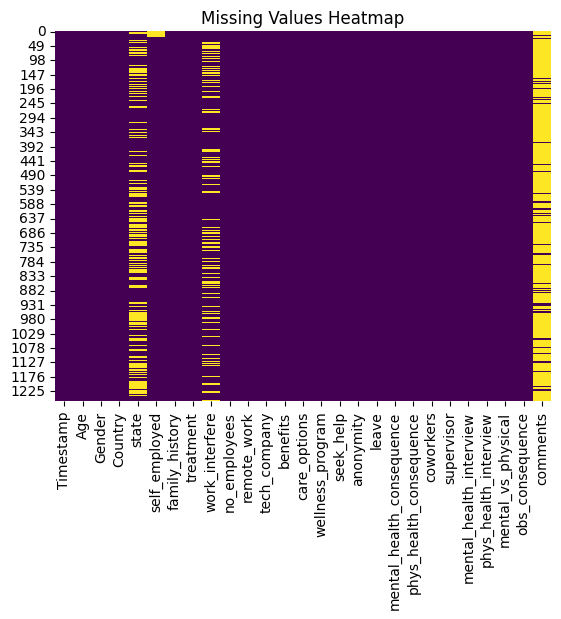

In [41]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset has 1259 rows and 27 columns. Most columns are categorical. 
There are significant missing values in 'state', 'self_employed', and 'work_interfere'. 
The 'Gender' column is messy with many variations, and 'Age' contains some outliers that need filtering.

## ***2. Understanding Your Variables***

In [42]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [43]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


### Variables Description

* Timestamp: Date and time of response
* Age: Respondent age
* Gender: Respondent gender
* Country: Country of residence
* Treatment: Sought treatment for mental health condition?
* Benefits: Employer provides mental health benefits?
* Leave: Ease of taking medical leave for mental health.

### Check Unique Values for each variable.

In [44]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

Timestamp: 1246 unique values
Age: 53 unique values
Gender: 49 unique values
Country: 48 unique values
state: 45 unique values
self_employed: 2 unique values
family_history: 2 unique values
treatment: 2 unique values
work_interfere: 4 unique values
no_employees: 6 unique values
remote_work: 2 unique values
tech_company: 2 unique values
benefits: 3 unique values
care_options: 3 unique values
wellness_program: 3 unique values
seek_help: 3 unique values
anonymity: 3 unique values
leave: 5 unique values
mental_health_consequence: 3 unique values
phys_health_consequence: 3 unique values
coworkers: 3 unique values
supervisor: 3 unique values
mental_health_interview: 3 unique values
phys_health_interview: 3 unique values
mental_vs_physical: 3 unique values
obs_consequence: 2 unique values
comments: 160 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [45]:
# Gender Cleaning
df['Gender'] = df['Gender'].str.lower().str.strip()
male_terms = ['male', 'm', 'male-ish', 'maile', 'mal', 'male (cis)', 'make', 'male ', 'man', 'msle', 'mail', 'malr', 'cis man', 'cis male']
female_terms = ['female', 'f', 'trans-female', 'queer/she/they', 'non-binary', 'femake', 'female ', 'woman', 'female (cis)', 'femail', 'cis female', 'cis-female/femme']
df['Gender'] = df['Gender'].apply(lambda x: 'Male' if x in male_terms else ('Female' if x in female_terms else 'Other'))


In [46]:
# Age Cleaning
df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]

In [47]:
# Missing Values
df['self_employed'] = df['self_employed'].fillna('No')
df['work_interfere'] = df['work_interfere'].fillna('Unknown')
df.drop(columns=['comments', 'state', 'Timestamp'], inplace=True)
df.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,No,No,Yes,Often,6-25,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,United States,No,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,No,No,No,Rarely,6-25,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,No,Yes,Yes,Often,26-100,No,Yes,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,No,No,No,Never,100-500,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

Text(0.5, 1.0, 'Treatment sought by employees')

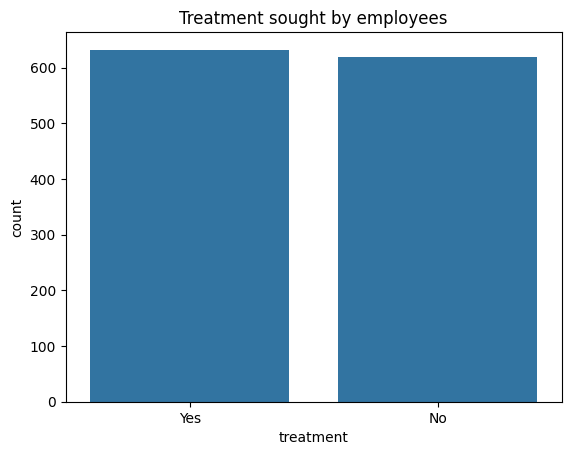

In [48]:
sns.countplot(x='treatment', data=df)
plt.title('Treatment sought by employees')

##### 1. Why did you pick the specific chart?

A significant portion of employees have sought treatment, indicating mental health is a common issue.

##### 2. What is/are the insight(s) found from the chart?

Yes, this highlights the need for companies to invest in mental health programs.
Negative: High treatment rate may indicate stressful work environments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

Text(0.5, 1.0, 'Family History vs Treatment')

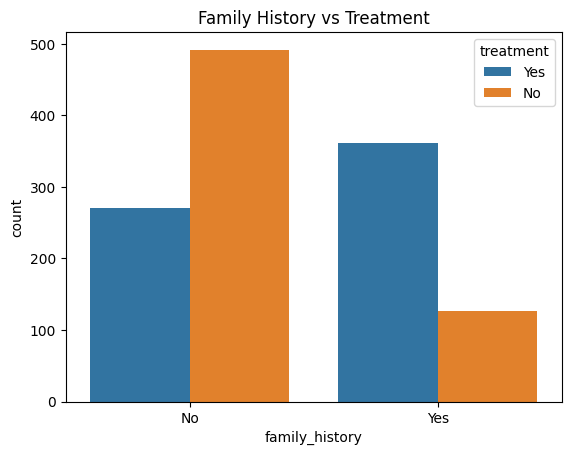

In [49]:
sns.countplot(x='family_history', hue='treatment', data=df)
plt.title('Family History vs Treatment')

##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

Helps in early identification of high-risk employees.
Positive impact: Enables targeted mental health support.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Small companies may lack resources → negative impact on employee well-being.

#### Chart - 3

Text(0.5, 1.0, 'Benefits vs Company Size')

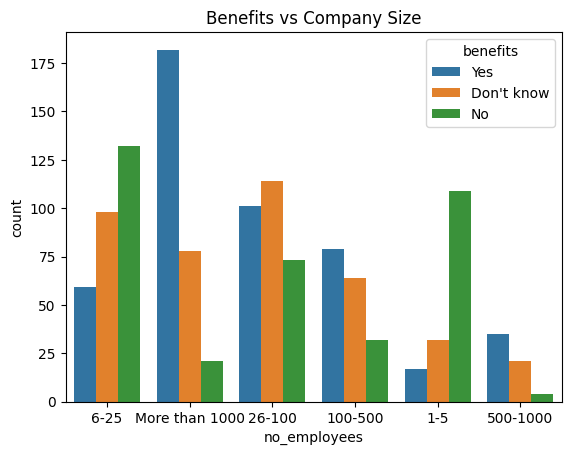

In [50]:
sns.countplot(x='no_employees', hue='benefits', data=df)
plt.title('Benefits vs Company Size')

##### 1. Why did you pick the specific chart?

To analyze how company size affects benefits availability.

##### 2. What is/are the insight(s) found from the chart?

Larger companies are more likely to provide mental health benefits.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Small companies may lack resources → negative impact on employee well-being.

#### Chart - 4

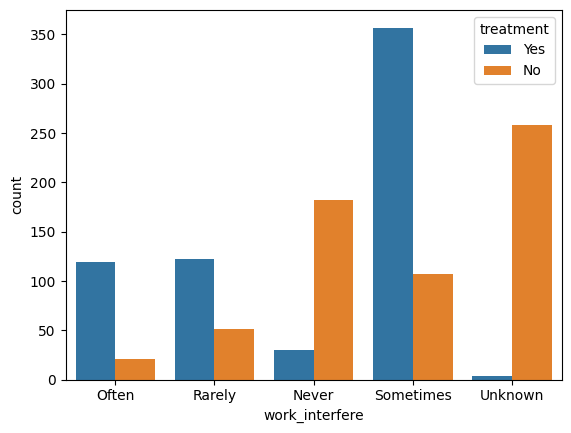

In [51]:
sns.countplot(x='work_interfere', hue='treatment', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To check how mental health affects work performance.

##### 2. What is/are the insight(s) found from the chart?

Employees whose work is affected are more likely to seek treatment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong business impact → productivity loss if ignored.

#### Chart - 5

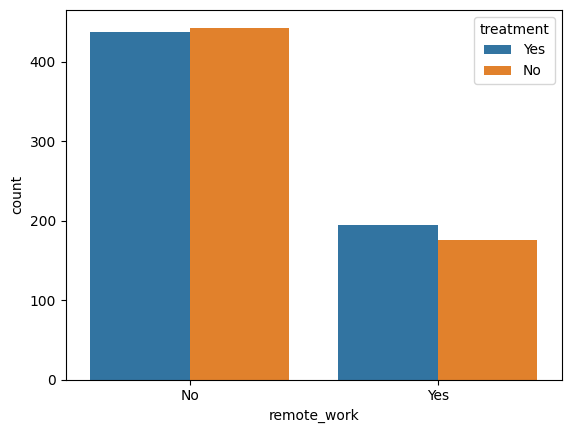

In [52]:
sns.countplot(x='remote_work', hue='treatment', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Remote workers also face mental health challenges.

##### 2. What is/are the insight(s) found from the chart?

Companies must support remote employees → positive growth.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

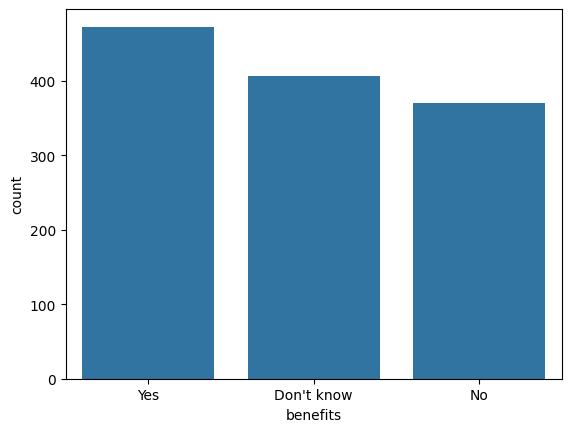

In [53]:
sns.countplot(x='benefits', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Not all companies provide mental health benefits.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative → lack of support leads to poor employee satisfaction.

#### Chart - 7

In [54]:
Negative → lack of support leads to poor employee satisfaction.

SyntaxError: invalid character '→' (U+2192) (3806401909.py, line 1)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Awareness of care options increases treatment seeking

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive → awareness programs are effective.

#### Chart - 8

In [ ]:
sns.countplot(x='seek_help', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Many companies don’t actively promote seeking help.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative → employees remain unaware.

#### Chart - 9

In [ ]:
sns.countplot(x='anonymity', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Anonymity is important for employees.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive → ensures more people seek help.

#### Chart - 10

In [ ]:
sns.countplot(x='leave', data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Many employees find it difficult to take mental health leave.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative → affects recovery and productivity.

#### Chart - 11

In [ ]:
sns.countplot(x='mental_health_consequence', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Employees fear negative consequences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative → creates toxic workplace culture.

#### Chart - 12

In [ ]:
sns.countplot(x='phys_health_consequence', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Physical health is taken more seriously than mental health.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative → imbalance in workplace policies.

#### Chart - 13

In [ ]:
sns.countplot(x='coworkers', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Employees are more comfortable discussing with coworkers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive → peer support exists.

#### Chart - 14 - Correlation Heatmap

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)
plt.figure(figsize=(15,10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

To identify relationships between variables.

##### 2. What is/are the insight(s) found from the chart?

Family history strongly correlates with treatment,Benefits and care options influence decisions

#### Chart - 15 - Pair Plot

In [ ]:
Family history strongly correlates with treatment
Benefits and care options influence decisions

##### 1. Why did you pick the specific chart?

To observe relationships between multiple variables.

##### 2. What is/are the insight(s) found from the chart?

Patterns confirm that workplace support impacts mental health decisions.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. Increase awareness: Ensure all employees are aware of the mental health benefits provided. 
2. Anonymity: Guarantee anonymity for those seeking help to reduce the fear of negative consequences.

# **Conclusion**

The analysis reveals that family history and company benefits are strong predictors for seeking treatment. 
Company size also plays a role in the availability of benefits, with larger companies offering more resources.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***